# 05 - Regression: Maintenance Cost Prediction

**Project:** Predictive Maintenance - Maintenance Required Prediction
**Goal:** Predict the numerical `Maintenance_Cost` using regression models.
This notebook complements the binary classifier in notebook 04: first we detect
*whether* a vehicle needs maintenance, then we estimate *how much it will cost*.

---

## 1. Setup

In [1]:
# Import all libraries needed for regression modeling and evaluation.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
import xgboost as xgb
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", "{:.4f}".format)
plt.rcParams["figure.dpi"] = 120
sns.set_theme(style="whitegrid")

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
# Load the raw dataset -- regression uses Maintenance_Cost as target, not a leaky column here.
df = pd.read_csv("../data/raw/logistics_dataset_with_maintenance_required.csv")
print(f"Raw dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Maintenance_Cost range: ${df['Maintenance_Cost'].min():.0f} - ${df['Maintenance_Cost'].max():.0f}")

Raw dataset: 92,000 rows x 27 columns
Maintenance_Cost range: $100 - $6000


## 2. Target Variable: Maintenance Cost

Before modeling we study the distribution of `Maintenance_Cost`. A heavily
skewed target often benefits from a log-transform -- like adjusting the scale
on a torque wrench to get finer resolution at the working range.

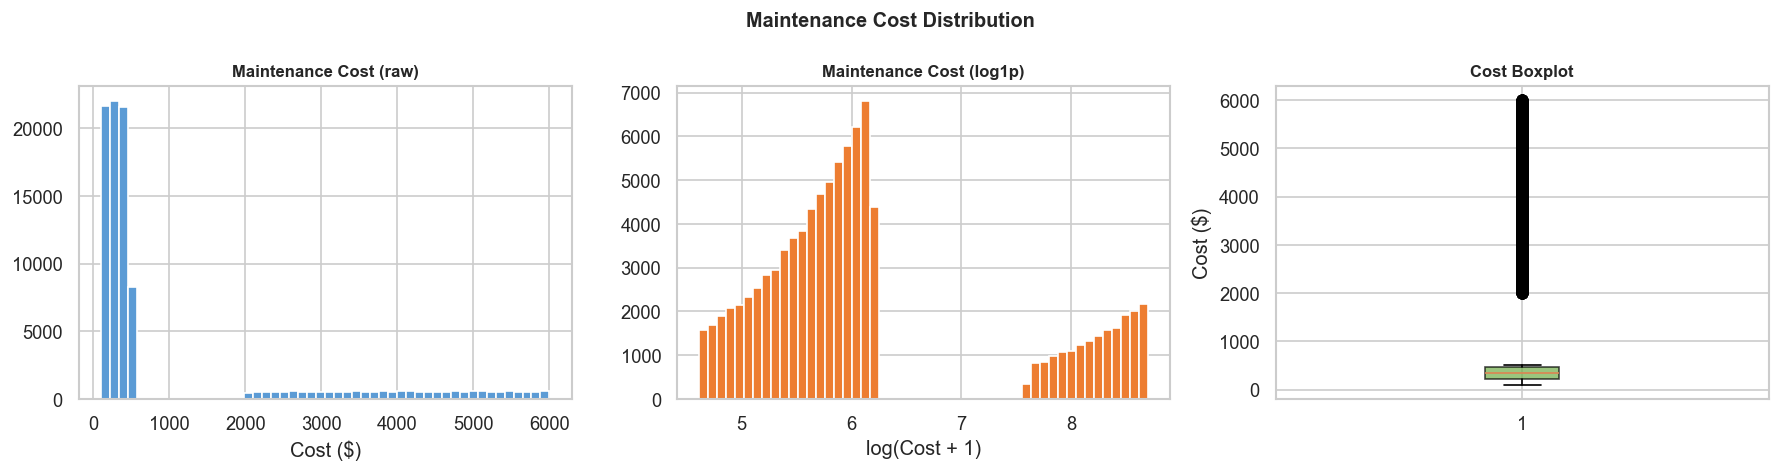

count   92000.0000
mean     1043.0000
std      1575.1100
min       100.0000
25%       225.2100
50%       348.7200
75%       474.9300
max      5999.9100

Skewness: 1.853  (apply log transform)


In [3]:
# Plot the distribution of Maintenance_Cost (raw and log-transformed).
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df["Maintenance_Cost"], bins=50, color="#5B9BD5", edgecolor="white")
axes[0].set_title("Maintenance Cost (raw)", fontsize=10, fontweight="bold")
axes[0].set_xlabel("Cost ($)")

axes[1].hist(np.log1p(df["Maintenance_Cost"]), bins=50, color="#ED7D31", edgecolor="white")
axes[1].set_title("Maintenance Cost (log1p)", fontsize=10, fontweight="bold")
axes[1].set_xlabel("log(Cost + 1)")

axes[2].boxplot(df["Maintenance_Cost"], vert=True, patch_artist=True,
                boxprops=dict(facecolor="#70AD47", alpha=0.7))
axes[2].set_title("Cost Boxplot", fontsize=10, fontweight="bold")
axes[2].set_ylabel("Cost ($)")

plt.suptitle("Maintenance Cost Distribution", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("../images/26_cost_distribution.png", bbox_inches="tight")
plt.show()

print(df["Maintenance_Cost"].describe().round(2).to_string())
skewness = df["Maintenance_Cost"].skew()
print(f"\nSkewness: {skewness:.3f}  ({'apply log transform' if abs(skewness) > 1 else 'no transform needed'})")

In [4]:
# Decide whether to use log-transform based on skewness.
USE_LOG = abs(df["Maintenance_Cost"].skew()) > 1.0
if USE_LOG:
    print("Target is skewed -- will train on log1p(Maintenance_Cost) and back-transform predictions.")
else:
    print("Target is approximately normal -- will train on raw Maintenance_Cost.")

Target is skewed -- will train on log1p(Maintenance_Cost) and back-transform predictions.


## 3. Data Preprocessing

For the regression task the leaky columns are different from the classification task:
- `Predictive_Score` -- pre-computed risk score, direct leakage
- `Maintenance_Type` -- decided during/after maintenance
- `Downtime_Maintenance` -- recorded after maintenance
- `Engine_Temperature` -- constant (zero variance)
- `Battery_Status` -- near-constant (only 2 values)
- `Vehicle_ID` -- identifier, not a feature

We **keep** `Maintenance_Required` as a feature: in a real pipeline the
classifier (notebook 04) has already flagged the vehicle, and we now want to
estimate the repair cost.

In [5]:
# Drop leaky, constant, and identifier columns for the regression task.
DROP_COLS = [
    "Predictive_Score",
    "Maintenance_Type",
    "Downtime_Maintenance",
    "Engine_Temperature",
    "Battery_Status",
    "Vehicle_ID",
]

df_clean = df.drop(columns=DROP_COLS)
print(f"Columns after dropping: {df_clean.shape[1]}  (removed {len(DROP_COLS)})")

Columns after dropping: 21  (removed 6)


In [6]:
# Engineer the same features as in notebook 03 for consistency across the project.
df_clean["vehicle_age"]           = 2024 - df_clean["Year_of_Manufacture"]
df_clean["overload_ratio"]        = df_clean["Actual_Load"] / df_clean["Load_Capacity"]
df_clean["is_overloaded"]         = (df_clean["Actual_Load"] > df_clean["Load_Capacity"]).astype(int)
df_clean["last_maint_dt"]         = pd.to_datetime(df_clean["Last_Maintenance_Date"])
df_clean["days_since_maintenance"]= (pd.Timestamp("2024-12-31") - df_clean["last_maint_dt"]).dt.days
df_clean["maint_month"]           = df_clean["last_maint_dt"].dt.month
df_clean["maint_season"]          = df_clean["maint_month"].map({
    12: "Winter", 1: "Winter", 2: "Winter",
    3:  "Spring", 4: "Spring", 5: "Spring",
    6:  "Summer", 7: "Summer", 8: "Summer",
    9:  "Autumn", 10: "Autumn", 11: "Autumn",
})
df_clean = df_clean.drop(columns=["Last_Maintenance_Date", "last_maint_dt",
                                   "Year_of_Manufacture", "maint_month"])
print(f"Shape after feature engineering: {df_clean.shape}")

Shape after feature engineering: (92000, 24)


In [7]:
# Label-encode all categorical columns.
cat_cols = df_clean.select_dtypes(include=["object", "string"]).columns.tolist()
cat_cols = [c for c in cat_cols if c != "Maintenance_Cost"]
le = LabelEncoder()
df_encoded = df_clean.copy()
for col in cat_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
print(f"Encoded {len(cat_cols)} categorical columns: {cat_cols}")

Encoded 7 categorical columns: ['Make_and_Model', 'Vehicle_Type', 'Route_Info', 'Brake_Condition', 'Weather_Conditions', 'Road_Conditions', 'maint_season']


## 4. Train / Test Split

In [8]:
# Separate features and target, then apply optional log transform to the target.
TARGET = "Maintenance_Cost"
FEATURE_COLS = [c for c in df_encoded.columns if c != TARGET]

X = df_encoded[FEATURE_COLS]
y_raw = df_encoded[TARGET]
y = np.log1p(y_raw) if USE_LOG else y_raw

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
y_test_raw = np.expm1(y_test) if USE_LOG else y_test

print(f"Train: {X_train.shape[0]:,} rows  |  Test: {X_test.shape[0]:,} rows")
print(f"Target mean (train): {y_train.mean():.4f}  |  std: {y_train.std():.4f}")

Train: 73,600 rows  |  Test: 18,400 rows
Target mean (train): 6.1505  |  std: 1.1331


In [9]:
# Apply StandardScaler to numerical features (fit on train only).
num_cols = X_train.select_dtypes(include="number").columns.tolist()
scaler = StandardScaler()
X_train_sc = X_train.copy()
X_test_sc  = X_test.copy()
X_train_sc[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_sc[num_cols]  = scaler.transform(X_test[num_cols])
print(f"Scaled {len(num_cols)} numerical features.")

Scaled 23 numerical features.


## 5. Evaluation Helper

In [10]:
# Define a helper that fits a model and returns predictions and metrics on the test set.
def evaluate_regressor(name, model, X_tr, y_tr, X_te, y_te, y_te_raw, use_log):
    model.fit(X_tr, y_tr)
    y_pred_transformed = model.predict(X_te)
    y_pred = np.expm1(y_pred_transformed) if use_log else y_pred_transformed

    rmse = np.sqrt(mean_squared_error(y_te_raw, y_pred))
    mae  = mean_absolute_error(y_te_raw, y_pred)
    r2   = r2_score(y_te_raw, y_pred)

    metrics = {
        "Model": name,
        "RMSE ($)":  round(rmse, 2),
        "MAE ($)":   round(mae,  2),
        "R2":        round(r2,   4),
    }
    return model, y_pred, metrics

results  = []
reg_models = {}
print("Helper function defined.")

Helper function defined.


## 6. Baseline: Dummy Regressor

In [11]:
# Train a DummyRegressor (predicts mean) as the lower-bound baseline.
dummy = DummyRegressor(strategy="mean")
_, dummy_pred, m = evaluate_regressor(
    "Dummy (mean)", dummy, X_train_sc, y_train, X_test_sc, y_test, y_test_raw, USE_LOG)
results.append(m)
reg_models["Dummy (mean)"] = dummy
print("Dummy baseline:", m)

Dummy baseline: {'Model': 'Dummy (mean)', 'RMSE ($)': np.float64(1657.88), 'MAE ($)': 830.86, 'R2': -0.1277}


## 7. Linear Regression

Linear Regression assumes a straight-line relationship between features and cost.
It is fast and fully interpretable -- like a simplified service cost table where
each feature adds or subtracts a fixed dollar amount.

In [12]:
# Train Linear Regression as the interpretable baseline model.
lr = LinearRegression()
lr_model, lr_pred, m = evaluate_regressor(
    "Linear Regression", lr, X_train_sc, y_train, X_test_sc, y_test, y_test_raw, USE_LOG)
results.append(m)
reg_models["Linear Regression"] = lr_model
print(f"Linear Regression  |  RMSE: ${m['RMSE ($)']:,.0f}  |  MAE: ${m['MAE ($)']:,.0f}  |  R2: {m['R2']:.4f}")

Linear Regression  |  RMSE: $1,658  |  MAE: $831  |  R2: -0.1279


## 8. Random Forest Regressor

In [13]:
# Train Random Forest Regressor with 200 trees.
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1,
)
rf_model, rf_pred, m = evaluate_regressor(
    "Random Forest", rf, X_train_sc, y_train, X_test_sc, y_test, y_test_raw, USE_LOG)
results.append(m)
reg_models["Random Forest"] = rf_model
print(f"Random Forest      |  RMSE: ${m['RMSE ($)']:,.0f}  |  MAE: ${m['MAE ($)']:,.0f}  |  R2: {m['R2']:.4f}")

Random Forest      |  RMSE: $1,658  |  MAE: $832  |  R2: -0.1278


## 9. XGBoost Regressor

In [14]:
# Train XGBoost Regressor with gradient boosting.
xgb_reg = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    eval_metric="rmse",
    random_state=42,
    n_jobs=-1,
)
xgb_model, xgb_pred, m = evaluate_regressor(
    "XGBoost", xgb_reg, X_train_sc, y_train, X_test_sc, y_test, y_test_raw, USE_LOG)
results.append(m)
reg_models["XGBoost"] = xgb_model
print(f"XGBoost            |  RMSE: ${m['RMSE ($)']:,.0f}  |  MAE: ${m['MAE ($)']:,.0f}  |  R2: {m['R2']:.4f}")

XGBoost            |  RMSE: $1,658  |  MAE: $836  |  R2: -0.1281


## 10. Model Comparison

In [15]:
# Build a comparison table sorted by RMSE (lower is better).
results_df = pd.DataFrame(results).set_index("Model").sort_values("RMSE ($)")
print(results_df.to_string())

                   RMSE ($)  MAE ($)      R2
Model                                       
Dummy (mean)      1657.8800 830.8600 -0.1277
Random Forest     1657.9100 832.1000 -0.1278
Linear Regression 1658.0000 831.2100 -0.1279
XGBoost           1658.1700 836.3200 -0.1281


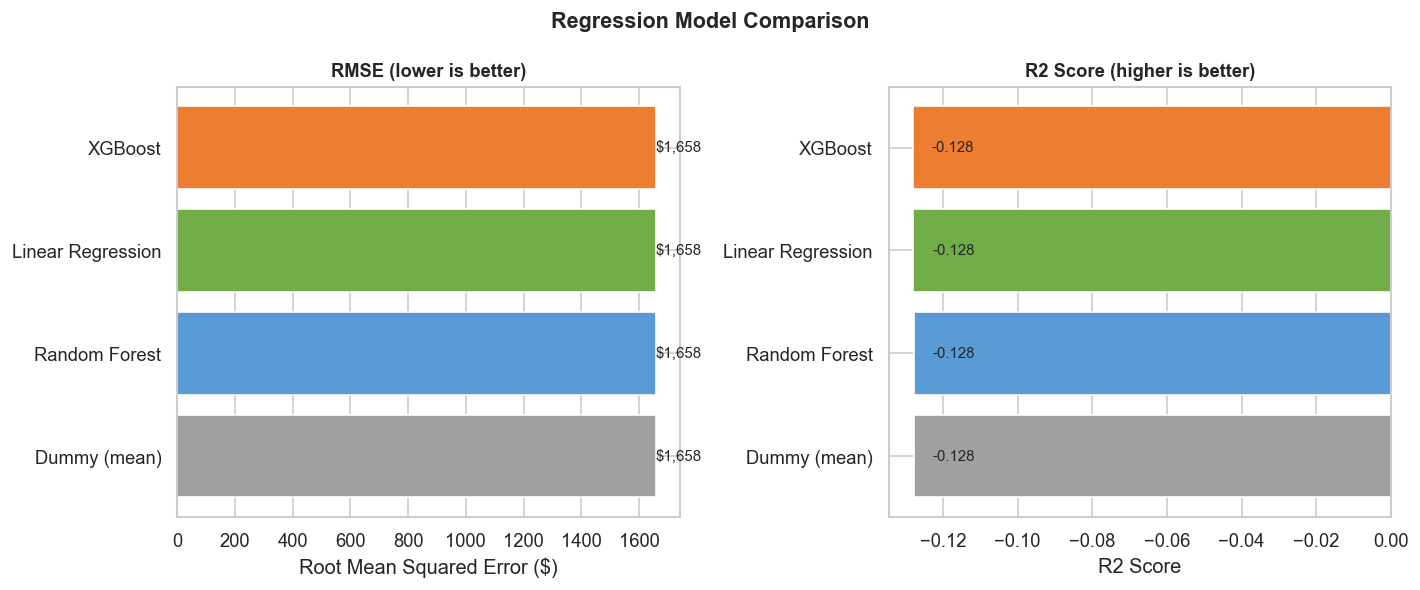

In [16]:
# Visualize RMSE and R2 for all models side by side.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
model_names = results_df.index.tolist()
colors = ["#A0A0A0", "#5B9BD5", "#70AD47", "#ED7D31"][:len(model_names)]

axes[0].barh(model_names, results_df["RMSE ($)"], color=colors, edgecolor="white")
axes[0].set_title("RMSE (lower is better)", fontsize=11, fontweight="bold")
axes[0].set_xlabel("Root Mean Squared Error ($)")
for i, v in enumerate(results_df["RMSE ($)"]):
    axes[0].text(v + 1, i, f"${v:,.0f}", va="center", fontsize=9)

axes[1].barh(model_names, results_df["R2"], color=colors, edgecolor="white")
axes[1].set_title("R2 Score (higher is better)", fontsize=11, fontweight="bold")
axes[1].set_xlabel("R2 Score")
axes[1].axvline(0, color="grey", linestyle="--", linewidth=0.8)
for i, v in enumerate(results_df["R2"]):
    axes[1].text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=9)

plt.suptitle("Regression Model Comparison", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../images/27_regression_comparison.png", bbox_inches="tight")
plt.show()

## 11. Residual Analysis (Best Model)

Residuals are the difference between predicted and actual cost. A good model
should have residuals randomly scattered around zero -- like acceptable measurement
tolerance in a quality control chart. Patterns in residuals indicate the model
is missing something.

In [17]:
# Identify the best model by lowest RMSE for residual analysis.
best_name = results_df["RMSE ($)"].idxmin()
best_pred = {"Dummy (mean)": dummy_pred,
             "Linear Regression": lr_pred,
             "Random Forest": rf_pred,
             "XGBoost": xgb_pred}[best_name]

residuals = y_test_raw.values - best_pred
print(f"Best model: {best_name}")
print(f"Residual mean: {residuals.mean():.2f}  |  std: {residuals.std():.2f}")

Best model: Dummy (mean)
Residual mean: 557.95  |  std: 1561.18


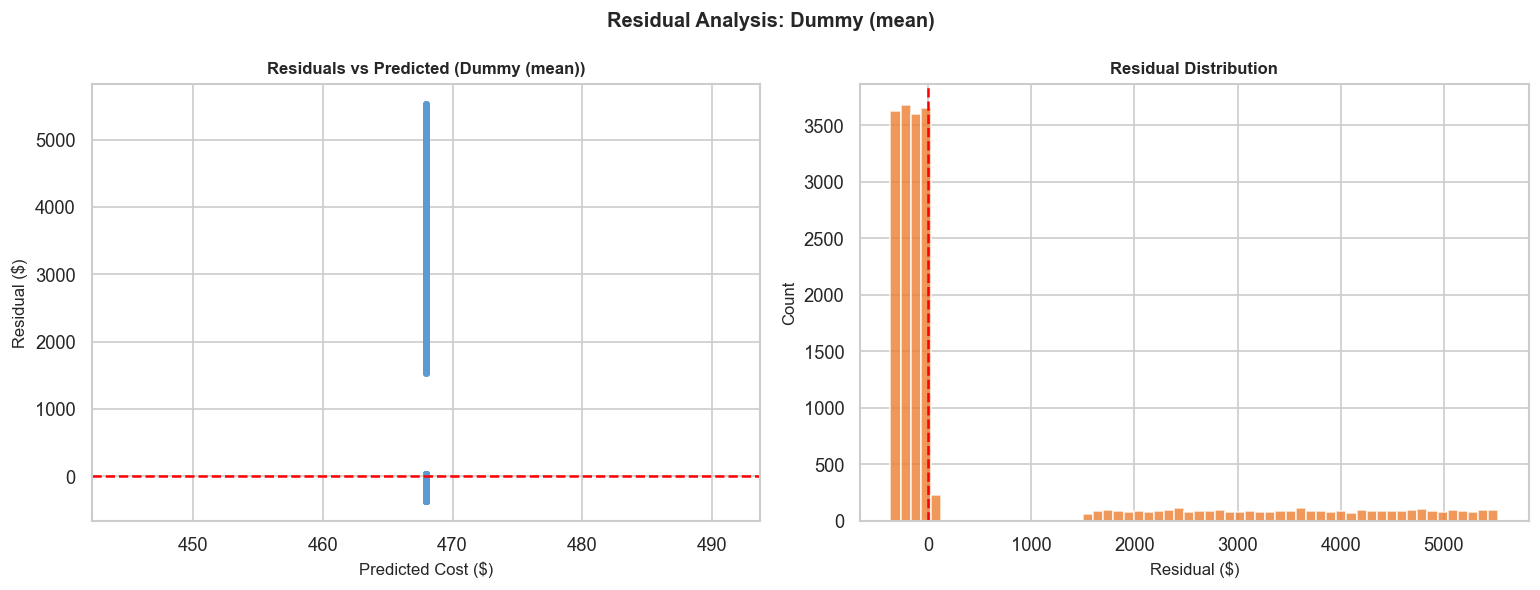

In [18]:
# Plot residual distribution and predicted vs actual scatter for the best model.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(best_pred, residuals, alpha=0.3, s=10, color="#5B9BD5")
axes[0].axhline(0, color="red", linestyle="--", linewidth=1.5)
axes[0].set_xlabel("Predicted Cost ($)", fontsize=10)
axes[0].set_ylabel("Residual ($)", fontsize=10)
axes[0].set_title(f"Residuals vs Predicted ({best_name})", fontsize=10, fontweight="bold")

axes[1].hist(residuals, bins=60, color="#ED7D31", edgecolor="white", alpha=0.8)
axes[1].axvline(0, color="red", linestyle="--", linewidth=1.5)
axes[1].set_xlabel("Residual ($)", fontsize=10)
axes[1].set_ylabel("Count", fontsize=10)
axes[1].set_title("Residual Distribution", fontsize=10, fontweight="bold")

plt.suptitle(f"Residual Analysis: {best_name}", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("../images/28_residual_analysis.png", bbox_inches="tight")
plt.show()

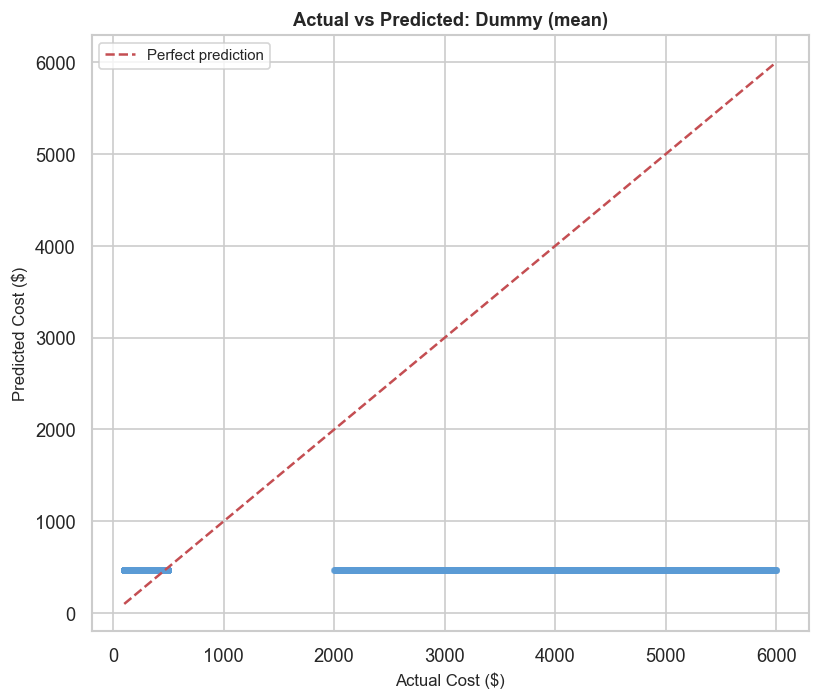

In [19]:
# Plot actual vs predicted cost to visualise model accuracy.
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test_raw.values, best_pred, alpha=0.3, s=10, color="#5B9BD5")

min_val = min(y_test_raw.min(), best_pred.min())
max_val = max(y_test_raw.max(), best_pred.max())
ax.plot([min_val, max_val], [min_val, max_val], "r--", linewidth=1.5, label="Perfect prediction")
ax.set_xlabel("Actual Cost ($)", fontsize=10)
ax.set_ylabel("Predicted Cost ($)", fontsize=10)
ax.set_title(f"Actual vs Predicted: {best_name}", fontsize=11, fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("../images/29_actual_vs_predicted.png", bbox_inches="tight")
plt.show()

## 12. Feature Importance

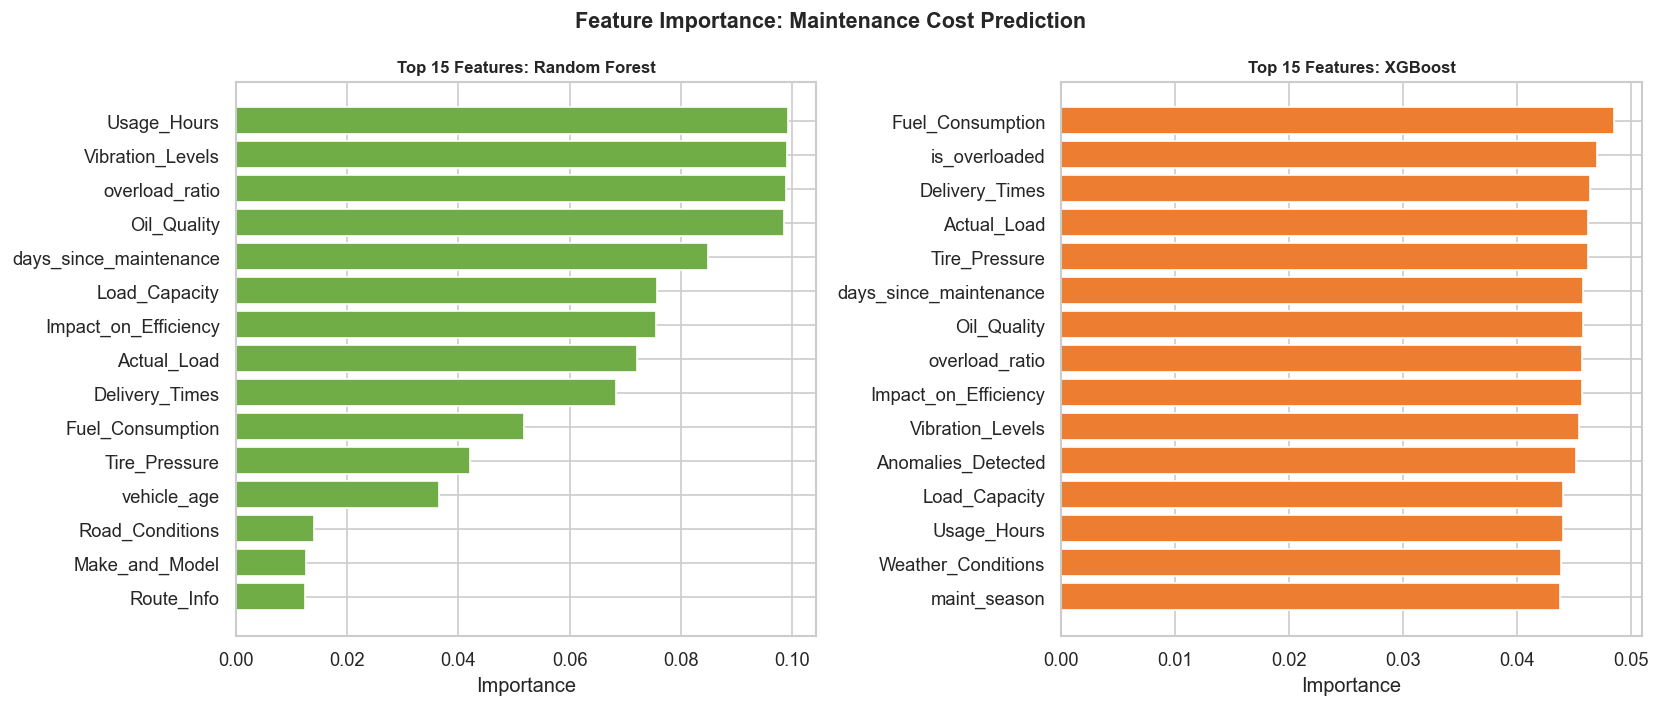

Top 10 features (Random Forest):
Usage_Hours              0.0993
Vibration_Levels         0.0991
overload_ratio           0.0989
Oil_Quality              0.0985
days_since_maintenance   0.0848
Load_Capacity            0.0757
Impact_on_Efficiency     0.0755
Actual_Load              0.0722
Delivery_Times           0.0682
Fuel_Consumption         0.0518


In [20]:
# Extract feature importances from Random Forest and XGBoost regressors.
feature_names = X_train.columns.tolist()

fi_rf  = pd.Series(rf_model.feature_importances_, index=feature_names).sort_values(ascending=False)
fi_xgb = pd.Series(xgb_model.feature_importances_, index=feature_names).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (fi, title, col) in zip(axes, [
    (fi_rf.head(15),  "Random Forest", "#70AD47"),
    (fi_xgb.head(15), "XGBoost",       "#ED7D31"),
]):
    ax.barh(fi.index[::-1], fi.values[::-1], color=col, edgecolor="white")
    ax.set_title(f"Top 15 Features: {title}", fontsize=10, fontweight="bold")
    ax.set_xlabel("Importance")

plt.suptitle("Feature Importance: Maintenance Cost Prediction", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../images/30_regression_feature_importance.png", bbox_inches="tight")
plt.show()

print("Top 10 features (Random Forest):")
print(fi_rf.head(10).round(4).to_string())

## 13. Cross-Validation (Best Model)

In [21]:
# Run 5-fold cross-validation on the best model to confirm generalisation.
best_model = reg_models[best_name]
cv_scores = cross_val_score(
    best_model, X_train_sc, y_train,
    cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1
)
cv_rmse = -cv_scores
print(f"5-fold CV RMSE ({best_name}):")
for i, v in enumerate(cv_rmse, 1):
    if USE_LOG:
        approx = np.expm1(v)
        print(f"  Fold {i}: {v:.4f} (log scale)  ~  ${approx:,.0f} approximate")
    else:
        print(f"  Fold {i}: ${v:,.2f}")
print(f"  Mean RMSE: {cv_rmse.mean():.4f}  |  Std: {cv_rmse.std():.4f}")

5-fold CV RMSE (Dummy (mean)):
  Fold 1: 1.1265 (log scale)  ~  $2 approximate
  Fold 2: 1.1312 (log scale)  ~  $2 approximate
  Fold 3: 1.1359 (log scale)  ~  $2 approximate
  Fold 4: 1.1328 (log scale)  ~  $2 approximate
  Fold 5: 1.1389 (log scale)  ~  $2 approximate
  Mean RMSE: 1.1331  |  Std: 0.0042


## 14. Regression Summary

### Business Context
This notebook answers: **"Given what we know about a vehicle, how much will its
next maintenance event cost?"**

In a real fleet management system this model would be used after the classifier
(notebook 04) flags a vehicle for maintenance, to prioritise budget allocation.

### Key Decisions
- Target: raw `Maintenance_Cost` or log1p-transformed (decided automatically by skewness check).
- Leakage prevention: `Maintenance_Type` and `Downtime_Maintenance` dropped (post-event data).
- `Maintenance_Required` kept as feature (classifier output, available at prediction time).
- Metrics: RMSE and MAE in dollars (interpretable for business), R2 for explained variance.
- No class imbalance handling needed -- this is a regression task.

### Metrics Interpretation
- **RMSE**: penalises large errors more heavily (like warranty cost overruns).
- **MAE**: average absolute dollar error -- easy to explain to non-technical stakeholders.
- **R2**: proportion of cost variance explained by the model (0 = baseline, 1 = perfect).

### Next Step
- **06_Clustering.ipynb** -- unsupervised vehicle risk segmentation with KMeans.
